# 4. Política de decisión y juego secuencial de costos

## Resumen y propósito
Primero se elige aprobar, revisar o escalar cada transacción; luego se decide mantener el modelo, recalibrar umbrales con etiquetas maduras o reentrenar. La recompensa semanal es el negativo del costo. Se compara con **aprobar todo sin modelo** bajo los mismos datos futuros.

## Supuestos visibles
Todas las cantidades son **USD ilustrativos**, no tarifas de una entidad real. Fraude aprobado: `4.41 × TransactionAmt`; revisión: USD 2 más pérdida residual si falla; legítima escalada: USD 10; fraude escalado: 5 % de pérdida residual; actualización: USD 100 central. Se evalúan eficacias de revisión 60/80/100 %, costos de actualización 0/100/500 y fricción 5/10/25. Los umbrales se eligen en validación. El cupo diario se fija antes del holdout usando 5 % de la mediana de volumen diario del train inicial.

In [1]:
import json, os
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

FINAL_ROOT = Path.cwd() if (Path.cwd() / 'v01_features.json').exists() else Path.cwd() / 'final'
__file__ = str(FINAL_ROOT / 'common.py')
V01_FEATURES = ['V258', 'C5', 'D1n', 'D3', 'C13', 'C1', 'C14', 'card1', 'D2n', 'card2', 'TransactionAmt', 'D15n', 'addr1', 'D2', 'D10n', 'C11', 'card6_label', 'P_emaildomain_label', 'C6', 'card5', 'D4', 'M4_freq', 'V257', 'D15', 'C2', 'C8', 'dist1', 'card3', 'card6_freq', 'C9', 'P_emaildomain_freq', 'D8', 'M4_label', 'M5_label', 'D1', 'D10', 'C10', 'M5_freq', 'id_02', 'C4', 'DT_hour', 'ProductCD_label', 'R_emaildomain_label', 'V189', 'V45', 'V243', 'D5', 'M6_freq', 'DeviceInfo_label', 'id_20', 'TransactionAmt_log1p', 'D11', 'id_01', 'C12', 'V87', 'DeviceInfo_freq', 'V78', 'V201', 'id_19', 'id_13', 'V140', 'ProductCD_freq', 'missing_D_count', 'V262', 'id_05', 'V38', 'M6_label', 'card4_label', 'dist2', 'V156', 'id_14', 'id_06', 'M3_label', 'missing_V_count', 'R_emaildomain_freq', 'V149', 'id_17', 'card4_freq', 'V94', 'D13', 'V37', 'id_18', 'DeviceType_freq', 'V74', 'D6', 'id_32', 'V58', 'D14', 'id_09', 'D9', 'D12', 'V86', 'addr2', 'C7', 'C3', 'V64', 'V170', 'id_03', 'D7', 'V44', 'V47', 'V217', 'missing_core_count', 'V52', 'V23', 'TransactionAmt_outlier_iqr', 'V79', 'M3_freq', 'V148', 'V157', 'M2_label', 'V33', 'V171', 'M9_label', 'M7_label', 'missing_id_count', 'V57', 'V219', 'V81', 'V39', 'M8_label', 'V154', 'V199', 'M9_freq', 'V232', 'V63', 'V34', 'V177', 'id_11', 'V228', 'V233', 'V230', 'V40', 'V158', 'V146', 'V231', 'id_04', 'V60', 'V155', 'V200', 'V51', 'V188', 'id_24', 'V190', 'DeviceType_label', 'V50', 'M8_freq', 'V85', 'V252', 'V73', 'M2_freq', 'id_21', 'V147', 'V197', 'V153', 'M7_freq', 'V16', 'V72', 'V84', 'V246', 'V43', 'V15', 'id_08', 'id_26', 'id_25', 'V244', 'id_07', 'V247', 'M1_freq', 'V93', 'V42', 'V71', 'V18', 'V242', 'V92', 'V32', 'id_10', 'V80', 'M1_label', 'V21', 'V17', 'V22', 'V31', 'has_identity', 'id_22']
RUN_FULL = (os.name == 'posix' and Path('/kaggle/working').exists()) or os.getenv('PTDIA_RUN_FULL') == '1'
print('Ejecución completa:', RUN_FULL)

Ejecución completa: False


### Implementación reproducible
Las funciones siguientes son código ejecutable del proyecto. Se agrupan por responsabilidad y se pueden ejecutar de arriba abajo sin archivos auxiliares.

In [2]:
"""Shared, deterministic IEEE-CIS helpers for the four final notebooks.

The notebook entry points call these functions. Nothing is fitted on future
rows: a preprocessing instance is created for each historical training window.
"""

from __future__ import annotations

import gc
import gzip
import json
import os
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import average_precision_score, precision_score, recall_score

DAY = 86400
WEEK = 7 * DAY
SEED = 42
CAT_COLS = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"] + [f"M{i}" for i in range(1, 10)]
MONITOR_COLS = ["TransactionAmt", "D1n", "D2n", "D10n", "D15n", "C9", "id_02", "id_20", "D11", "id_01"]


def paths(stage: str):
    here = Path(__file__).resolve().parent
    candidates = [
        Path("/kaggle/input/ieee-fraud-detection"),
        Path("/kaggle/input/competitions/ieee-fraud-detection"),
        here.parent / "ieee-fraud-detection",
    ]
    data = next((p for p in candidates if (p / "train_transaction.csv").exists()), None)
    if data is None:
        raise FileNotFoundError("IEEE-CIS competition input unavailable")
    output = Path("/kaggle/working") if os.name == "posix" and Path("/kaggle/working").exists() else here / "kaggle" / stage / "outputs"
    output.mkdir(parents=True, exist_ok=True)
    (output / "plots").mkdir(exist_ok=True)
    return data, output


def manifest(output: Path, **values):
    target = output / "run_summary.json"
    current = json.loads(target.read_text()) if target.exists() else {}
    current.update(values)
    target.write_text(json.dumps(current, indent=2, default=float), encoding="utf-8")


def save_plot(output: Path, name: str):
    plt.tight_layout()
    plt.savefig(output / "plots" / name, dpi=140, bbox_inches="tight")
    plt.close()


def load_data(data: Path, include_test: bool = False):
    def one(prefix: str):
        txn = pd.read_csv(data / f"{prefix}_transaction.csv", low_memory=False)
        identity = pd.read_csv(data / f"{prefix}_identity.csv", low_memory=False)
        # IEEE-CIS test identity uses id-01 style names, while train uses id_01.
        identity.rename(columns=lambda c: c.replace("id-", "id_") if c.startswith("id-") else c, inplace=True)
        if txn.TransactionID.duplicated().any() or identity.TransactionID.duplicated().any():
            raise ValueError("TransactionID must be unique in each source")
        out = txn.merge(identity, on="TransactionID", how="left", validate="one_to_one", indicator="_identity_join")
        del txn, identity
        gc.collect()
        out["has_identity_join"] = out["_identity_join"].eq("both").astype("int8")
        out.drop(columns="_identity_join", inplace=True)
        out.sort_values(["TransactionDT", "TransactionID"], inplace=True)
        out.reset_index(drop=True, inplace=True)
        return out

    train = one("train")
    test = one("test") if include_test else None
    return train, test


def split_bounds(df: pd.DataFrame):
    return float(df.TransactionDT.quantile(0.70)), float(df.TransactionDT.quantile(0.85))


def split_name(dt: pd.Series, bounds: tuple[float, float]):
    return np.where(dt <= bounds[0], "train", np.where(dt <= bounds[1], "valid", "holdout"))


def row_features(df: pd.DataFrame):
    """Only own-row information. Fitted statistics are added by WindowEncoder."""
    out = df.copy()
    day = (out.TransactionDT // DAY).astype("int16")
    out["DT_hour"] = ((out.TransactionDT // 3600) % 24).astype("int8")
    out["DT_day_index"] = day
    out["DT_week_index"] = (day // 7).astype("int16")
    out["has_identity"] = out["has_identity_join"].astype("int8")
    out["TransactionAmt_log1p"] = np.log1p(out.TransactionAmt.clip(lower=0)).astype("float32")
    for family in ("V", "D", "id_"):
        cols = [c for c in out if c.startswith(family) and (family == "id_" or c[len(family):].isdigit())]
        out[f"missing_{family.replace('_', '')}_count"] = out[cols].isna().sum(axis=1).astype("int16") if cols else 0
    core = [c for c in ["card2", "card3", "card5", "addr1", "addr2", "dist1", "dist2"] if c in out]
    out["missing_core_count"] = out[core].isna().sum(axis=1).astype("int8")
    for col in ["D1", "D2", "D10", "D15"]:
        out[f"{col}n"] = (out[col] - day).astype("float32")
    return out


def candidate_uid(df: pd.DataFrame):
    parts = df[["card1", "card2", "card3", "card5", "addr1", "addr2"]].astype("string").fillna("NA")
    parts = parts.copy()
    parts["D1_anchor"] = (df.D1 - df.TransactionDT // DAY).round(0).astype("string").fillna("NA")
    return pd.util.hash_pandas_object(parts, index=False).astype("uint64")

In [3]:
def feature_list():
    here = Path(__file__).resolve().parent
    for path in (here / "v01_features.json", here / "input" / "v01_features.json"):
        if path.exists():
            return json.loads(path.read_text(encoding="utf-8"))
    if "V01_FEATURES" in globals():
        return list(globals()["V01_FEATURES"])
    raise FileNotFoundError("v01_features.json is required")


@dataclass
class WindowEncoder:
    features: list[str]
    q_low: float = 0.0
    q_high: float = 0.0
    maps: dict | None = None
    freqs: dict | None = None

    def fit(self, train: pd.DataFrame):
        q1, q3 = train.TransactionAmt.quantile([.25, .75])
        self.q_low, self.q_high = float(q1 - 1.5 * (q3 - q1)), float(q3 + 1.5 * (q3 - q1))
        self.maps, self.freqs = {}, {}
        for col in CAT_COLS:
            if col not in train:
                continue
            s = train[col].astype("string").fillna("__MISSING__")
            self.maps[col] = {v: i for i, v in enumerate(s.unique())}
            self.freqs[col] = (s.value_counts(dropna=False) / len(s)).to_dict()
        return self

    def transform(self, rows: pd.DataFrame):
        cols = {}
        for name in self.features:
            if name == "TransactionAmt_outlier_iqr":
                cols[name] = ((rows.TransactionAmt < self.q_low) | (rows.TransactionAmt > self.q_high)).astype("float32")
            elif name.endswith("_label") and name[:-6] in self.maps:
                col = name[:-6]
                cols[name] = rows[col].astype("string").fillna("__MISSING__").map(self.maps[col]).fillna(-1).astype("float32")
            elif name.endswith("_freq") and name[:-5] in self.freqs:
                col = name[:-5]
                cols[name] = rows[col].astype("string").fillna("__MISSING__").map(self.freqs[col]).fillna(0).astype("float32")
            elif name in rows:
                cols[name] = pd.to_numeric(rows[name], errors="coerce").astype("float32")
            else:
                cols[name] = pd.Series(np.nan, index=rows.index, dtype="float32")
        return pd.DataFrame(cols, index=rows.index).replace([np.inf, -np.inf], np.nan)


def psi(reference, current, bins=10):
    a = np.asarray(reference, dtype=float)
    b = np.asarray(current, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 100 or len(b) < 100:
        return np.nan
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0 if np.isclose(np.mean(a), np.mean(b)) else np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    pa = np.clip(np.histogram(a, edges)[0] / len(a), 1e-6, 1)
    pb = np.clip(np.histogram(b, edges)[0] / len(b), 1e-6, 1)
    return float(np.sum((pb - pa) * np.log(pb / pa)))


def safe_ap(y, pred):
    return float(average_precision_score(y, pred)) if len(y) and len(np.unique(y)) == 2 else np.nan


def evaluation_blocks(df: pd.DataFrame, bounds: tuple[float, float]):
    """Seven-day blocks clipped to each split; first valid week is label warm-up."""
    blocks = []
    for split, start, end in (("valid", bounds[0], bounds[1]), ("holdout", bounds[1], float(df.TransactionDT.max()) + 1)):
        index = 0
        t = start
        while t < end:
            u = min(t + WEEK, end)
            # First validation week warms up the seven-day label delay.
            if not (split == "valid" and index == 0):
                mask = (df.TransactionDT > t) & (df.TransactionDT <= u) if split == "valid" else (df.TransactionDT > t) & (df.TransactionDT < u)
                ix = df.index[mask].to_numpy()
                if len(ix):
                    blocks.append({"split": split, "block": index, "start": t, "end": u, "partial": u - t < WEEK, "indices": ix})
            t = u
            index += 1
    return blocks


def prediction_rows(df: pd.DataFrame, ix, uid_known, pred, model, strategy, window_days, block):
    return pd.DataFrame({
        "TransactionID": df.loc[ix, "TransactionID"].to_numpy(),
        "TransactionDT": df.loc[ix, "TransactionDT"].to_numpy(),
        "TransactionAmt": df.loc[ix, "TransactionAmt"].to_numpy(),
        "isFraud": df.loc[ix, "isFraud"].to_numpy(),
        "uid_known": uid_known,
        "score": np.asarray(pred),
        "model": model,
        "strategy": strategy,
        "window_days": window_days,
        "split": block["split"],
        "block": block["block"],
    })


def append_predictions(output: Path, rows: pd.DataFrame):
    path = output / "predictions.csv.gz"
    rows.to_csv(path, mode="at" if path.exists() else "wt", index=False, header=not path.exists(), compression="gzip")


def quick_cost(y, amount, score, review_fraction=.05, review_effectiveness=.8):
    """Offline same-capacity ranking proxy; operational queue is in policy notebook."""
    n = len(score)
    k = max(1, int(n * review_fraction))
    review = np.zeros(n, dtype=bool)
    review[np.argsort(score)[-k:]] = True
    loss = 4.41 * np.asarray(amount) * np.asarray(y)
    total = float(np.sum(np.where(review, 2 + (1 - review_effectiveness) * loss, loss)))
    return total / max(n, 1), float(recall_score(y, review, zero_division=0)), float(precision_score(y, review, zero_division=0))


def block_metrics(rows: pd.DataFrame, seconds=0.0, updated=False, device="none", psi_score=np.nan):
    y = rows.isFraud.to_numpy(dtype=int)
    p = rows.score.to_numpy(dtype=float)
    cost, recall, precision = quick_cost(y, rows.TransactionAmt, p)
    return {
        "model": rows.model.iloc[0], "strategy": rows.strategy.iloc[0], "window_days": rows.window_days.iloc[0],
        "split": rows.split.iloc[0], "block": int(rows.block.iloc[0]), "rows": len(rows),
        "fraud_rate": float(np.mean(y)), "pr_auc": safe_ap(y, p), "recall_at_5pct": recall,
        "precision_at_5pct": precision, "cost_per_txn_proxy": cost,
        "uid_known_pr_auc": safe_ap(y[rows.uid_known.to_numpy(dtype=bool)], p[rows.uid_known.to_numpy(dtype=bool)]),
        "uid_unknown_pr_auc": safe_ap(y[~rows.uid_known.to_numpy(dtype=bool)], p[~rows.uid_known.to_numpy(dtype=bool)]),
        "train_seconds": seconds, "updated": int(updated), "device": device, "psi_score": psi_score,
    }

In [4]:
def _model_outputs():
    here = Path(__file__).resolve().parent
    candidates = [here / "kaggle" / "experimentacion" / "outputs" / "predictions.csv.gz"]
    candidates += list(Path("/kaggle/input").glob("**/predictions.csv.gz")) if Path("/kaggle/input").exists() else []
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Model predictions missing; run 03_modelos_adaptacion first")


def _policy_actions(frame, low, high, daily_capacity):
    """Decisions in timestamp order, using only a fixed prior score threshold and a daily counter."""
    ordered = frame.sort_values(["TransactionDT", "TransactionID"]).copy()
    score = ordered.score.to_numpy(dtype=float)
    candidates = (score >= low) & (score < high)
    days = (ordered.TransactionDT // DAY).astype(int)
    order = pd.Series(candidates, index=ordered.index).groupby(days).cumsum().to_numpy()
    action = np.full(len(ordered), "approve", dtype="<U8")
    action[candidates & (order <= daily_capacity)] = "review"
    action[score >= high] = "escalate"
    ordered["action"] = action
    return ordered


def _policy_metrics(decisions, review_effectiveness=.8, update_cost=0.0, updates=0,
                    review_cost=2.0, false_escalation_cost=10.0):
    y = decisions.isFraud.to_numpy(dtype=bool)
    amount = decisions.TransactionAmt.to_numpy(dtype=float)
    action = decisions.action.to_numpy()
    loss = 4.41 * amount
    approved = action == "approve"
    reviewed = action == "review"
    escalated = action == "escalate"
    # Escalation means a temporary hold and manual confirmation. Assumed
    # prevention effectiveness is 95%, not a guaranteed outcome.
    direct = np.where(y & approved, loss, 0.0)
    direct += np.where(reviewed, review_cost + np.where(y, (1-review_effectiveness)*loss, 0.0), 0.0)
    direct += np.where(escalated, np.where(y, .05*loss, false_escalation_cost), 0.0)
    total = float(direct.sum() + update_cost*updates)
    legit = ~y
    return {
        "rows": len(y), "fraud_count": int(y.sum()), "cost_total": total,
        "cost_per_txn": total / max(len(y), 1), "reward_total": -total,
        "review_count": int(reviewed.sum()), "review_rate": float(reviewed.mean()),
        "escalate_count": int(escalated.sum()), "approve_count": int(approved.sum()),
        "fraud_approved": int((y & approved).sum()),
        "fraud_referred": int((y & (reviewed | escalated)).sum()),
        "fraud_referred_rate": float((y & (reviewed | escalated)).sum() / y.sum()) if y.any() else np.nan,
        "false_escalations_per_1000_legit": 1000*float((legit & escalated).sum() / legit.sum()) if legit.any() else np.nan,
        "updates": int(updates), "update_cost_total": float(update_cost*updates),
    }


def _optimize_thresholds(valid, daily_capacity):
    scores = valid.score.to_numpy(dtype=float)
    low_options = np.unique(np.quantile(scores, [.65, .75, .82, .88, .93]))
    high_options = np.unique(np.quantile(scores, [.96, .98, .99, .995]))
    best = None
    for low in low_options:
        for high in high_options:
            if low >= high:
                continue
            decisions = _policy_actions(valid, low, high, daily_capacity)
            metric = _policy_metrics(decisions)
            row = {"review_threshold": float(low), "escalate_threshold": float(high), **metric}
            if best is None or row["cost_per_txn"] < best["cost_per_txn"]:
                best = row
    if best is None:
        raise ValueError("No feasible policy thresholds")
    return best

In [5]:
def run_policy():
    data, out = paths("sistema_final")
    manifest(out, status="running", stage="load")
    path = _model_outputs()
    predictions = pd.read_csv(path, compression="gzip", low_memory=False)
    predictions["window_days"] = predictions.window_days.astype(str)
    predictions["uid_known"] = predictions.uid_known.astype(str).str.lower().eq("true")
    source = pd.read_csv(data / "train_transaction.csv", usecols=["TransactionDT"])
    train_cut = float(source.TransactionDT.quantile(.70))
    holdout_cut = float(source.TransactionDT.quantile(.85))
    day_counts = source.loc[source.TransactionDT <= train_cut].groupby(source.TransactionDT // DAY).size()
    daily_capacity = max(1, int(np.floor(.05 * day_counts.median())))
    del source
    gc.collect()

    fit_path = path.with_name("fit_log.csv")
    fit_log = pd.read_csv(fit_path) if fit_path.exists() else pd.DataFrame()
    groups = predictions.groupby(["model", "strategy", "window_days"], sort=False)
    results = []
    thresholds = []
    decisions_selected = []
    for (model, strategy, window_days), frame in groups:
        valid = frame.loc[frame.split == "valid"].copy()
        hold = frame.loc[frame.split == "holdout"].copy()
        if valid.empty or hold.empty:
            continue
        choice = _optimize_thresholds(valid, daily_capacity)
        thresholds.append({"model": model, "strategy": strategy, "window_days": window_days,
                           "daily_capacity": daily_capacity, "review_threshold": choice["review_threshold"],
                           "escalate_threshold": choice["escalate_threshold"],
                           "valid_cost_per_txn": choice["cost_per_txn"]})
        decided = _policy_actions(hold, choice["review_threshold"], choice["escalate_threshold"], daily_capacity)
        updates = 0
        if not fit_log.empty and strategy != "static":
            mask = ((fit_log.model == model) & (fit_log.strategy == strategy) &
                    (fit_log.window_days.astype(str) == window_days) & (fit_log.split == "holdout"))
            updates = int(mask.sum())
        for q in (.6, .8, 1.0):
            for update_cost in (0.0, 100.0, 500.0):
                for fp_cost in (5.0, 10.0, 25.0):
                    metric = _policy_metrics(decided, review_effectiveness=q, update_cost=update_cost,
                                             updates=updates, false_escalation_cost=fp_cost)
                    results.append({"model": model, "strategy": strategy, "window_days": window_days,
                                    "scenario": "model", "review_effectiveness": q,
                                    "update_cost": update_cost, "false_escalation_cost": fp_cost, **metric})
        if model == "lightgbm" and strategy == "static":
            decisions_selected.append(decided)
        # Release the many scenario columns before the next configuration.
        del valid, hold, decided
        gc.collect()

    if not decisions_selected:
        raise ValueError("V01 static decisions unavailable")
    static_hold = decisions_selected[0]
    no_model = static_hold.copy()
    no_model["action"] = "approve"
    baseline = _policy_metrics(no_model, review_effectiveness=.8)
    results.append({"model": "none", "strategy": "approve_all", "window_days": "none", "scenario": "no_model",
                    "review_effectiveness": .8, "update_cost": 0.0, "false_escalation_cost": 10.0, **baseline})

    # The recalibration action leaves the V01 model fixed. Thresholds are
    # reselected only from already mature prior out-of-sample predictions.
    static_all = predictions[(predictions.model == "lightgbm") & (predictions.strategy == "static")].copy()
    recalibrated_parts = []
    recalibration_log = []
    for block, current in static_all.loc[static_all.split == "holdout"].groupby("block", sort=True):
        start = holdout_cut + int(block) * WEEK
        available = static_all.loc[(static_all.TransactionDT < start - WEEK) &
                                   (static_all.TransactionDT >= start - 37*DAY)]
        if len(available) >= 3000 and available.isFraud.sum() >= 20:
            chosen = _optimize_thresholds(available, daily_capacity)
            low, high, reason = chosen["review_threshold"], chosen["escalate_threshold"], "matured_last_30d"
        else:
            row = next(t for t in thresholds if t["model"] == "lightgbm" and t["strategy"] == "static")
            low, high, reason = row["review_threshold"], row["escalate_threshold"], "initial_validation"
        recalibrated_parts.append(_policy_actions(current, low, high, daily_capacity))
        recalibration_log.append({"block": block, "known_before": start-WEEK, "reason": reason,
                                  "review_threshold": low, "escalate_threshold": high})
    recalibrated = pd.concat(recalibrated_parts, ignore_index=True)
    # Adjacent weekly blocks may split the same calendar day. Enforce the
    # shared daily review budget once across their combined decisions.
    recalibrated.sort_values(["TransactionDT", "TransactionID"], inplace=True)
    review_so_far = recalibrated.action.eq("review").groupby(recalibrated.TransactionDT // DAY).cumsum()
    recalibrated.loc[recalibrated.action.eq("review") & (review_so_far > daily_capacity), "action"] = "approve"
    metric = _policy_metrics(recalibrated, review_effectiveness=.8)
    results.append({"model": "lightgbm", "strategy": "recalibrate_thresholds", "window_days": "none",
                    "scenario": "model", "review_effectiveness": .8, "update_cost": 0.0,
                    "false_escalation_cost": 10.0, **metric})
    pd.DataFrame(recalibration_log).to_csv(out / "recalibration_log.csv", index=False)

    result = pd.DataFrame(results)
    result.to_csv(out / "policy_scenarios.csv", index=False)
    pd.DataFrame(thresholds).to_csv(out / "policy_thresholds_valid.csv", index=False)
    static_hold.to_csv(out / "v01_policy_decisions.csv.gz", index=False, compression="gzip")
    # Actual human review burden and false escalation by available UID segment.
    social = []
    for name, part in (("known", static_hold.loc[static_hold.uid_known]),
                       ("unknown", static_hold.loc[~static_hold.uid_known])):
        social.append({"uid_segment": name, **_policy_metrics(part, review_effectiveness=.8)})
    pd.DataFrame(social).to_csv(out / "social_uid_proxy.csv", index=False)

    central = result[(result.review_effectiveness == .8) & (result.update_cost == 100) &
                     (result.false_escalation_cost == 10)].copy()
    central = pd.concat([central, result[result.strategy.isin(["approve_all", "recalibrate_thresholds"])]], ignore_index=True)
    central.sort_values("cost_per_txn", inplace=True)
    central.to_csv(out / "central_comparison.csv", index=False)
    anchors = central.loc[central.strategy.isin(["approve_all", "static", "recalibrate_thresholds"])]
    anchors = anchors.loc[(anchors.strategy != "static") | (anchors.model == "lightgbm")]
    best = pd.concat([central.head(9), anchors]).drop_duplicates(
        ["model", "strategy", "window_days"]
    ).sort_values("cost_per_txn", ascending=False)
    fig, ax = plt.subplots(figsize=(9, 6))
    labels = [f"{r.model}/{r.strategy}/{r.window_days}" for r in best.itertuples()]
    ax.barh(labels, best.cost_per_txn, color="#4c78a8")
    ax.set(xlabel="USD ilustrativos por transaccion", title="Sin modelo frente a politicas: escenario central")
    save_plot(out, "01_costo_escenarios.png")

    selected = result[(result.model == "lightgbm") & (result.strategy.isin(["static", "periodic", "alert"])) &
                      (result.window_days.isin(["initial_70pct", "30"])) &
                      (result.false_escalation_cost == 10)]
    fig, ax = plt.subplots(figsize=(8, 5))
    for (strategy, window), part in selected.groupby(["strategy", "window_days"]):
        pivot = part.pivot_table(index="update_cost", columns="review_effectiveness", values="cost_per_txn")
        for q in pivot.columns:
            ax.plot(pivot.index, pivot[q], marker="o", label=f"{strategy}/{window}, revision {q:.0%}")
    ax.set(xlabel="Costo por actualizacion (USD supuestos)", ylabel="Costo por transaccion (USD)",
           title="Sensibilidad a revision y reentrenamiento")
    ax.legend(fontsize=8)
    save_plot(out, "02_sensibilidad.png")

    summary = {"status": "complete", "stage": "done", "daily_review_capacity": daily_capacity,
               "configurations": len(thresholds), "scenarios": len(result),
               "central_no_model_cost_per_txn": baseline["cost_per_txn"],
               "central_v01_cost_per_txn": float(central.loc[(central.model == "lightgbm") &
                                                           (central.strategy == "static"), "cost_per_txn"].iloc[0]),
               "costs_are": "illustrative_USD", "review_effectiveness": [0.6, 0.8, 1.0]}
    manifest(out, **summary)
    return out, summary

### Ejecutar o cargar la política
La simulación procesa transacciones cronológicamente con un contador diario de revisión; no usa etiquetas futuras para elegir la acción.

In [6]:
if RUN_FULL:
    output_dir, summary = run_policy()
else:
    output_dir = FINAL_ROOT / 'kaggle' / 'sistema_final' / 'outputs'
    summary_file = output_dir / 'run_summary.json'
    if not summary_file.exists():
        raise FileNotFoundError(f'Faltan outputs descargados: {summary_file}')
    summary = json.loads(summary_file.read_text(encoding='utf-8'))
print('Salidas:', output_dir)
display(pd.Series(summary, name='valor').to_frame())

Salidas: C:\Users\jeffr\GitHub\ptdia-proyecto1\final\kaggle\sistema_final\outputs


,valor
status,complete
stage,done
daily_review_capacity,158
configurations,27
scenarios,731
central_no_model_cost_per_txn,23.379433
central_v01_cost_per_txn,8.817917
costs_are,illustrative_USD
review_effectiveness,"[0.6, 0.8, 1.0]"


### Empresa sin modelo frente a empresa con modelo
El escenario central compara pérdidas, carga humana y fricción. La diferencia es un resultado de simulación con supuestos, no ahorro financiero observado.

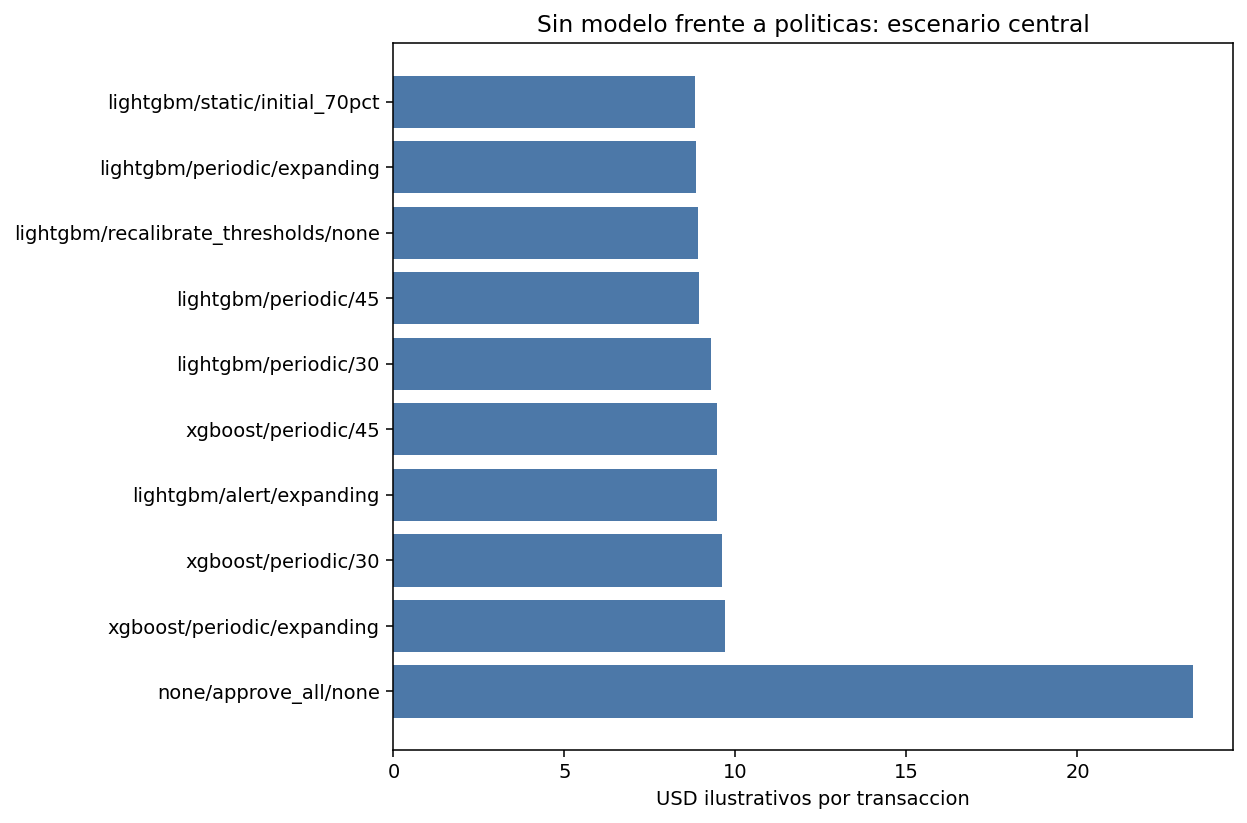

In [7]:
for name in ['01_costo_escenarios.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

### Resultado central e interpretación
    La validación seleccionó LightGBM periódico de 45 días por costo ilustrativo (**7.697** por transacción al incluir cuatro cargos de actualización, frente a **7.858** de V01); esa elección se llevó sin retocar umbrales al holdout. Allí, en 88 581 transacciones, aprobar todo cuesta **23.379**, V01 estático **8.818** y periódico 45 días **8.925**. La ventaja de validación no se sostuvo en costo final; por eso la recomendación de este escenario es mantener V01 y vigilarlo mientras se confirma con datos reales. El cupo diario fijado fue de **158** revisiones.

### Sensibilidad y costo de actualización
Cambiar eficacia humana y costo de entrenamiento puede invertir la preferencia entre políticas. Evitamos sumar una recompensa adicional por fraude prevenido cuando ya contabilizamos su pérdida evitada.

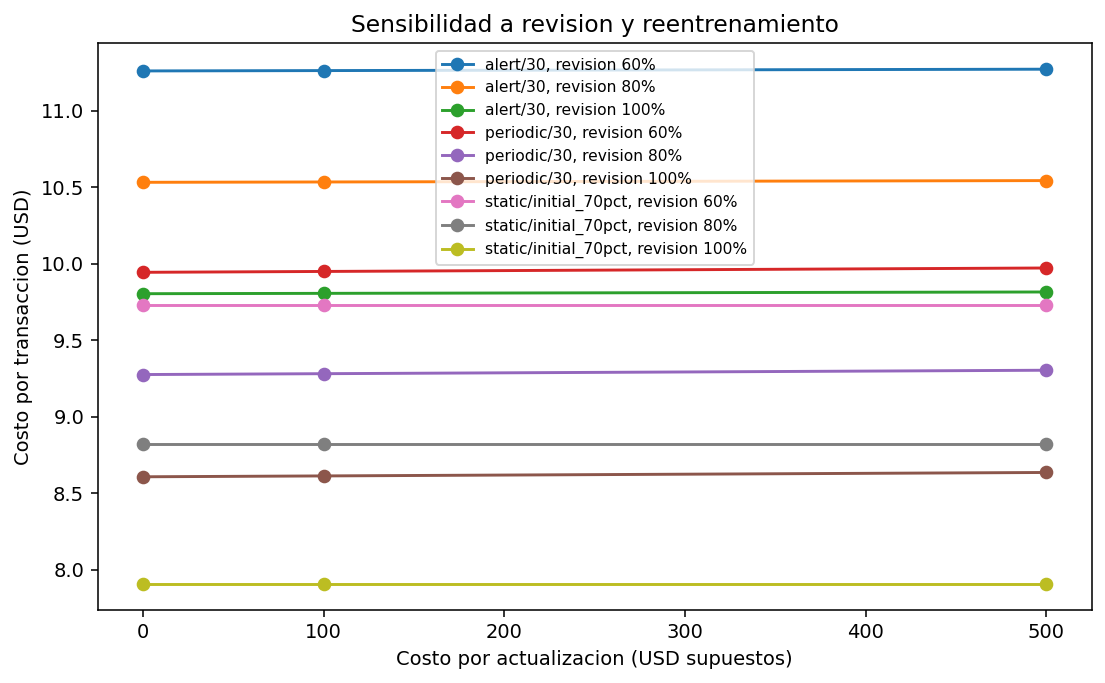

In [8]:
for name in ['02_sensibilidad.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

### Qué cambia con los supuestos
    Para V01, una eficacia de revisión de 60/80/100 % produce costos de **9.730 / 8.818 / 7.906** por transacción. El 100 % es optimista. Con cinco reentrenamientos en 88 581 operaciones, variar su costo unitario de USD 0 a 500 mueve poco el costo promedio; la eficacia humana tiene mayor efecto en los escenarios probados.

### Evidencia exacta y proxies sociales
En el escenario V01, las escalaciones falsas son 11.5 por 1 000 legítimas con UID conocido y 37.9 con UID desconocido. Esa fricción desigual requiere investigación operacional; UID no es una categoría demográfica. `policy_thresholds_valid.csv` documenta los umbrales elegidos en validación antes del holdout.

In [9]:
display(pd.read_csv(output_dir / 'central_comparison.csv').head(12)); display(pd.read_csv(output_dir / 'social_uid_proxy.csv'))

,model,strategy,window_days,scenario,review_effectiveness,update_cost,false_escalation_cost,rows,fraud_count,cost_total,...,review_count,review_rate,escalate_count,approve_count,fraud_approved,fraud_referred,fraud_referred_rate,false_escalations_per_1000_legit,updates,update_cost_total
0,lightgbm,static,initial_70pct,model,0.8,100.0,10.0,88581,3083,781099.936853,...,4892,0.055226,3768,79921,946,2137,0.693156,24.152612,0,0.0
1,lightgbm,periodic,expanding,model,0.8,100.0,10.0,88581,3083,784516.311554,...,4898,0.055294,4025,79658,869,2214,0.718132,26.012304,5,500.0
2,lightgbm,recalibrate_thresholds,none,model,0.8,0.0,10.0,88581,3083,789463.605159,...,4893,0.055238,3781,79907,952,2131,0.691210,24.281270,0,0.0
3,lightgbm,periodic,45,model,0.8,100.0,10.0,88581,3083,790552.993423,...,4898,0.055294,4015,79668,817,2266,0.734998,25.100002,5,500.0
4,lightgbm,periodic,30,model,0.8,100.0,10.0,88581,3083,822095.795055,...,4898,0.055294,4225,79458,836,2247,0.728836,27.088353,5,500.0
5,xgboost,periodic,45,model,0.8,100.0,10.0,88581,3083,837561.105945,...,4892,0.055226,3933,79756,882,2201,0.713915,25.240356,5,500.0
6,lightgbm,alert,expanding,model,0.8,100.0,10.0,88581,3083,838488.294174,...,4898,0.055294,4119,79564,898,2185,0.708725,27.719947,1,100.0
7,xgboost,periodic,30,model,0.8,100.0,10.0,88581,3083,850914.450319,...,4898,0.055294,4175,79508,880,2203,0.714564,27.415846,5,500.0
8,xgboost,periodic,expanding,model,0.8,100.0,10.0,88581,3083,858444.294831,...,4898,0.055294,4130,79553,981,2102,0.681803,28.445110,5,500.0
9,catboost,alert,45,model,0.8,100.0,10.0,88581,3083,862055.813877,...,4898,0.055294,4004,79679,995,2088,0.677262,27.486023,1,100.0


,uid_segment,rows,fraud_count,cost_total,cost_per_txn,reward_total,review_count,review_rate,escalate_count,approve_count,fraud_approved,fraud_referred,fraud_referred_rate,false_escalations_per_1000_legit,updates,update_cost_total
0,known,45684,1120,252019.069548,5.516572,-252019.069548,1511,0.033075,1014,43159,403,717,0.640179,11.489094,0,0.0
1,unknown,42897,1963,529080.867305,12.333750,-529080.867305,3381,0.078817,2754,36762,543,1420,0.723383,37.939122,0,0.0


## Defensa ante preguntas del docente
- **Leakage:** se excluyen identificador y tiempo absoluto; los estadísticos se ajustan por ventana. No puede garantizarse la disponibilidad operacional de todas las variables anonimizadas.
- **Autonomía:** la aprobación de bajo riesgo puede ser automática; el riesgo intermedio usa revisión y el alto riesgo, retención temporal con confirmación humana antes de un bloqueo irreversible.
- **Nube u on-premises:** el diseño usa contenedor, interfaz de score y almacenamiento intercambiables. La elección requiere comparar latencia, privacidad, operación y costo completo, no solo el precio del servidor.
- **Costo de inferencia:** separar tiempo medido de scoring del costo monetario estimado por solicitud. El tiempo del experimento no incluye red, servicio ni observabilidad.
- **Impacto social y de negocio:** comparar el mismo holdout con aprobar todo y con cada política; reportar pérdida simulada, fraude omitido, revisión y legítimas escaladas. La equidad demográfica no es verificable aquí.